# Exploratory Data Analysis and Sampling Strategy

## Project Objective
The goal of this analysis is to explore the relationships between student lifestyle, academic, and behavioral factors and the level of depression.

## Target Variable
The target variable selected for this analysis is `depression`.

## Research Question
Which academic, behavioral, and lifestyle factors are most associated with depression among students?

## Hypotheses
1. Higher stress levels are associated with higher depression levels.
2. Lower sleep hours are associated with higher depression levels.
3. Higher social media usage and screen time are associated with higher depression levels.
4. Better motivation, concentration, and self-discipline are associated with lower depression levels.
5. Since the target variable is continuous, the dataset will be treated as a regression problem.

## Step 1: Import Libraries
In this step, the required Python libraries are imported for data loading, inspection, visualization, and sampling.

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2: Load the Dataset
The dataset is loaded into a pandas DataFrame so it can be inspected and analyzed.

In [85]:
df = pd.read_csv(r"college_students_habits_1M.csv")

## Step 3: Inspect the Dataset Structure
This step is used to understand the dataset size, column names, data types, and a preview of the first rows.
This helps identify the target variable, feature types, and whether the dataset contains time or group-related columns.

In [86]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (1000000, 42)

Columns:
['study_hours', 'attendance', 'assignment_completion', 'midterm_score', 'final_score', 'project_score', 'backlogs', 'sleep_hours', 'stress', 'anxiety', 'depression', 'motivation', 'concentration', 'time_management', 'self_discipline', 'social_media_hours', 'gaming_hours', 'netflix_hours', 'screen_time', 'physical_activity', 'junk_food_frequency', 'caffeine_mg', 'late_night_frequency', 'procrastination_score', 'family_income', 'parental_education_level', 'internet_quality', 'library_visits', 'online_courses_completed', 'part_time_hours', 'peer_study_group', 'relationship_status', 'hostel_student', 'extracurricular_hours', 'phone_unlocks_per_day', 'previous_gpa', 'class_participation', 'weekly_study_sessions', 'group_study_hours', 'financial_stress', 'gpa', 'performance_level']

First 5 rows:
   study_hours  attendance  assignment_completion  midterm_score  final_score  \
0     3.014684    67.00599              51.595387      57.211285    61.6535

## Step 4: Define the Target Variable
The target variable for this analysis is `depression`, which represents the depression level of students.
This target will be examined to determine whether the problem should be treated as classification or regression.

In [87]:
target_col = "depression"
print("Target column:", target_col)

Target column: depression


## Step 5: Check Missing Values
Missing values are examined to understand the quality of the dataset and to determine whether preprocessing is needed before sampling and deeper analysis.

In [88]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nMissing value percentage:")
print((df.isnull().mean() * 100).round(2))

Missing values per column:
study_hours                    0
attendance                     0
assignment_completion          0
midterm_score                  0
final_score                    0
project_score                  0
backlogs                       0
sleep_hours                    0
stress                         0
anxiety                        0
depression                     0
motivation                     0
concentration                  0
time_management                0
self_discipline                0
social_media_hours             0
gaming_hours                   0
netflix_hours                  0
screen_time                    0
physical_activity              0
junk_food_frequency            0
caffeine_mg                    0
late_night_frequency           0
procrastination_score          0
family_income                  0
parental_education_level       0
internet_quality               0
library_visits                 0
online_courses_completed       0
part_time_hours 

## Step 6: Check for Duplicate Rows
Duplicate rows are checked because they may bias the analysis and affect the representativeness of the sample.

In [89]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Step 7: Examine the Target Variable
This step is used to understand the nature of the target variable.
If the target has many numeric values, the problem is treated as regression.
If the target contains a few categories, the problem is treated as classification.

In [90]:
print("Target data type:", df[target_col].dtype)
print("\nNumber of unique values in target:", df[target_col].nunique())

print("\nTarget summary statistics:")
print(df[target_col].describe())

Target data type: float64

Number of unique values in target: 964263

Target summary statistics:
count    1000000.000000
mean          44.991453
std           14.991202
min            0.000000
25%           34.862051
50%           44.973913
75%           55.099820
max          100.000000
Name: depression, dtype: float64


## Step 8: Visualize the Distribution of the Target
A histogram is plotted to understand the distribution of depression values.
This helps determine whether the target is continuous and whether the distribution is skewed or approximately normal.

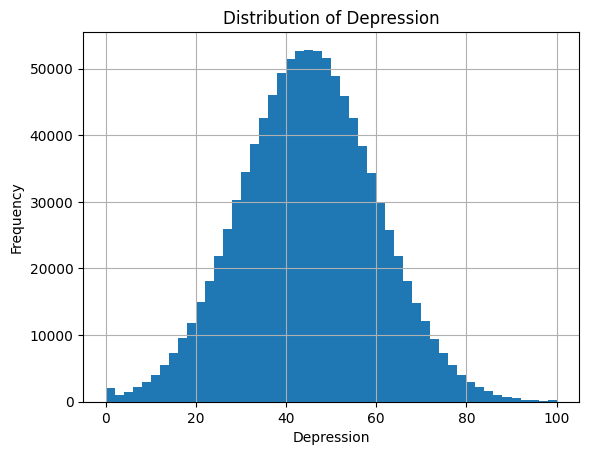

In [91]:
df[target_col].hist(bins=50)
plt.title("Distribution of Depression")
plt.xlabel("Depression")
plt.ylabel("Frequency")
plt.show()

## Step 9: Identify the Problem Type
Based on the number of unique values and the histogram of the target variable, `depression` is treated as a continuous variable.
Therefore, this analysis is considered a regression problem rather than a classification problem.

In [92]:
if df[target_col].nunique() > 20:
    print("The target variable is continuous. This is a regression problem.")
else:
    print("The target variable is categorical. This is a classification problem.")

The target variable is continuous. This is a regression problem.


## Step 10: Check for Time Structure
This step checks whether the dataset contains time-related columns such as dates or timestamps.
If such columns exist and row order matters, time-based sampling may be required.

In [93]:
print("Columns:")
print(df.columns.tolist())

Columns:
['study_hours', 'attendance', 'assignment_completion', 'midterm_score', 'final_score', 'project_score', 'backlogs', 'sleep_hours', 'stress', 'anxiety', 'depression', 'motivation', 'concentration', 'time_management', 'self_discipline', 'social_media_hours', 'gaming_hours', 'netflix_hours', 'screen_time', 'physical_activity', 'junk_food_frequency', 'caffeine_mg', 'late_night_frequency', 'procrastination_score', 'family_income', 'parental_education_level', 'internet_quality', 'library_visits', 'online_courses_completed', 'part_time_hours', 'peer_study_group', 'relationship_status', 'hostel_student', 'extracurricular_hours', 'phone_unlocks_per_day', 'previous_gpa', 'class_participation', 'weekly_study_sessions', 'group_study_hours', 'financial_stress', 'gpa', 'performance_level']


### Conclusion
No time-related columns such as `date`, `timestamp`, or `created_at` were found in the dataset.
Therefore, the dataset does not have temporal structure, and time-based sampling is not required.

## Step 11: Check for Group Structure
This step checks whether the dataset contains identifier columns such as `student_id`, `user_id`, or `customer_id`.
If multiple rows belong to the same entity, group-aware sampling may be necessary.

In [94]:
print("Columns:")
print(df.columns.tolist())

Columns:
['study_hours', 'attendance', 'assignment_completion', 'midterm_score', 'final_score', 'project_score', 'backlogs', 'sleep_hours', 'stress', 'anxiety', 'depression', 'motivation', 'concentration', 'time_management', 'self_discipline', 'social_media_hours', 'gaming_hours', 'netflix_hours', 'screen_time', 'physical_activity', 'junk_food_frequency', 'caffeine_mg', 'late_night_frequency', 'procrastination_score', 'family_income', 'parental_education_level', 'internet_quality', 'library_visits', 'online_courses_completed', 'part_time_hours', 'peer_study_group', 'relationship_status', 'hostel_student', 'extracurricular_hours', 'phone_unlocks_per_day', 'previous_gpa', 'class_participation', 'weekly_study_sessions', 'group_study_hours', 'financial_stress', 'gpa', 'performance_level']


### Conclusion
No group identifier column such as `student_id` or `user_id` was found in the dataset.
This suggests that each row represents an independent observation rather than repeated measurements of the same student.
Therefore, group-based sampling is not required.

## Step 12: Sampling Decision
The following conclusions were drawn from the exploratory checks:

- The target variable `depression` is continuous.
- The dataset does not contain time-related columns.
- The dataset does not contain group identifier columns.
- The observations appear to be independent.
- There is no special structure that must be preserved during sampling.

Based on these findings, simple random sampling is the most appropriate sampling method for this dataset.

## Step 13: Apply Simple Random Sampling
Simple random sampling is applied to select a representative subset of the dataset.
This method is appropriate because the data is not grouped, not time-ordered, and the target variable is continuous.

In [95]:
df_sample = df.sample(frac=0.1, random_state=42)

print("Original shape:", df.shape)
print("Sample shape:", df_sample.shape)

Original shape: (1000000, 42)
Sample shape: (100000, 42)


## Step 14: Validate the Sample
The sample is compared to the full dataset using summary statistics of the target variable.
If the statistics are close, the sample can be considered reasonably representative.

In [96]:
print("Original depression mean:", df[target_col].mean())
print("Sample depression mean:", df_sample[target_col].mean())

print("\nOriginal depression std:", df[target_col].std())
print("Sample depression std:", df_sample[target_col].std())

Original depression mean: 44.99145297219754
Sample depression mean: 44.951999642673805

Original depression std: 14.991202051679972
Sample depression std: 15.055963305613217


## Step 15: Compare the Original and Sample Distributions
A visual comparison is made between the target distribution in the original dataset and in the sampled dataset.
This helps confirm whether the sample preserves the overall shape of the data.

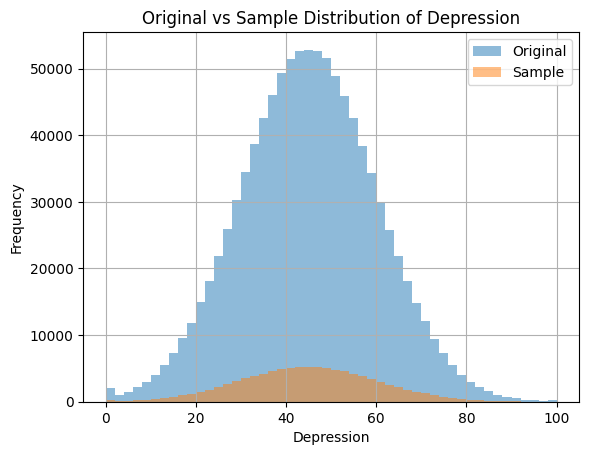

In [97]:
df[target_col].hist(bins=50, alpha=0.5, label="Original")
df_sample[target_col].hist(bins=50, alpha=0.5, label="Sample")
plt.title("Original vs Sample Distribution of Depression")
plt.xlabel("Depression")
plt.ylabel("Frequency")
plt.legend()
plt.show()

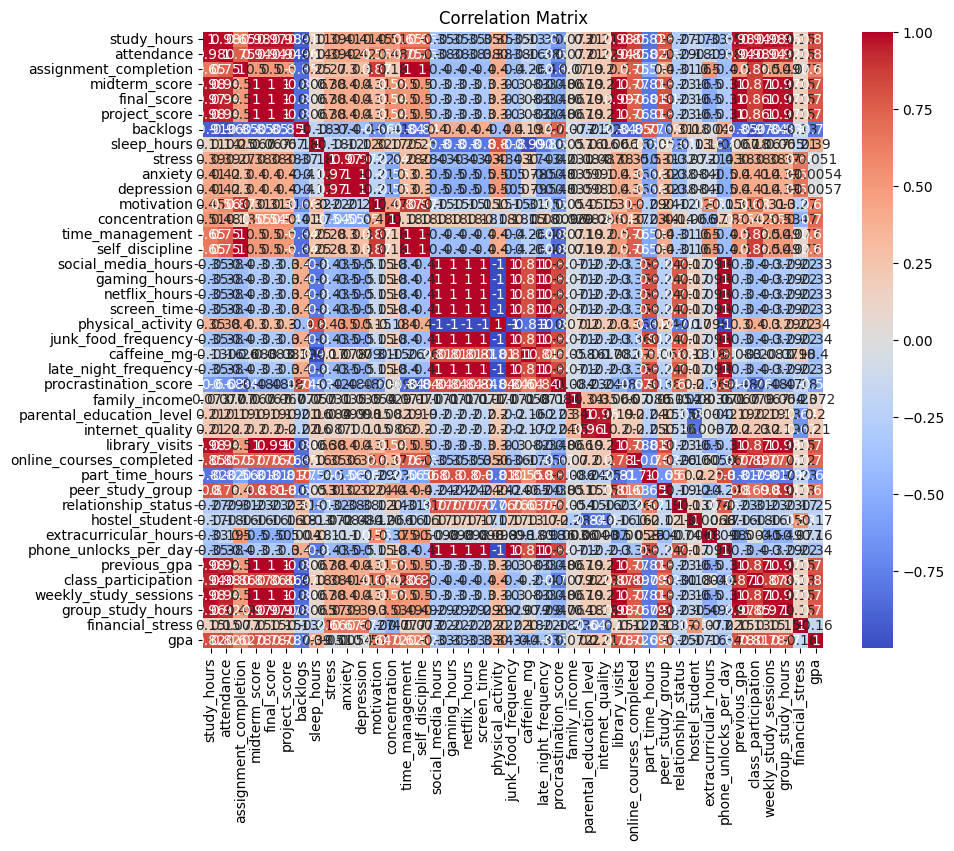

In [98]:
corr = df_sample.corr(numeric_only=True)

import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Since the map is has too much information, we need to focus on the features relationship with depression only.

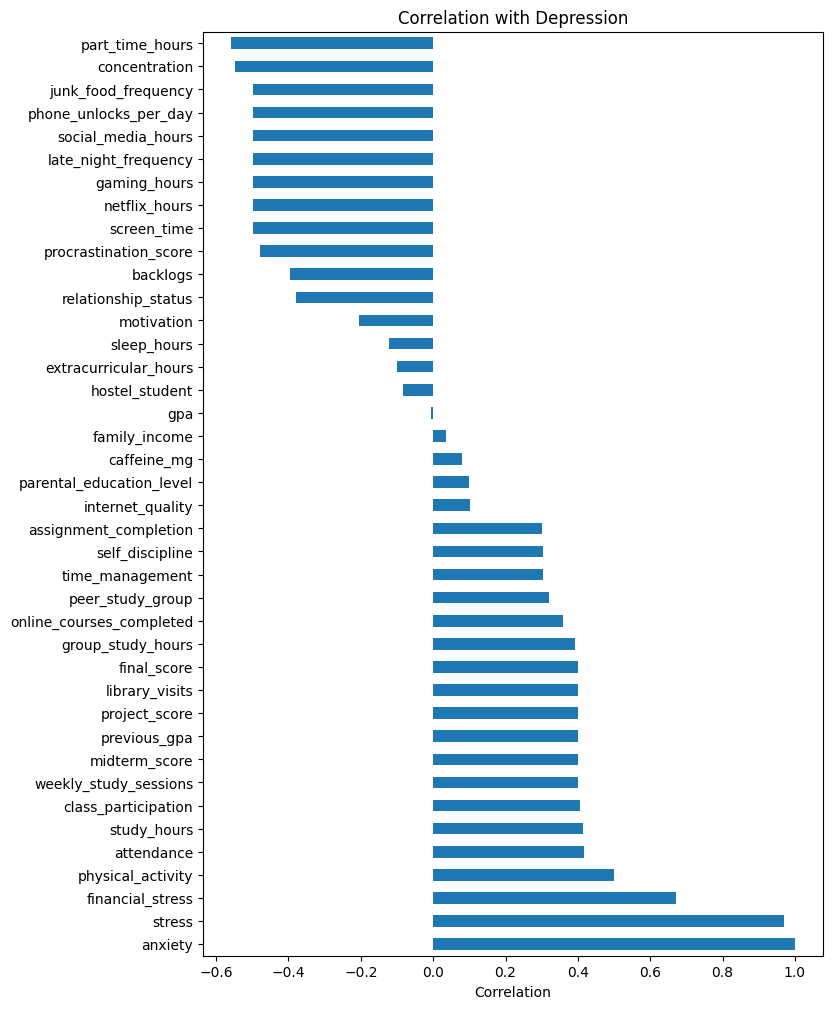

In [99]:
corr_target = df_sample.corr(numeric_only=True)["depression"].sort_values(ascending=False)

plt.figure(figsize=(8, 12))
corr_target.drop("depression").plot(kind="barh")
plt.title("Correlation with Depression")
plt.xlabel("Correlation")
plt.show()

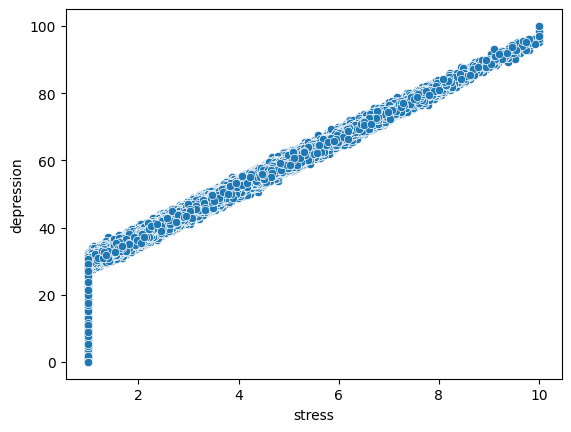

In [100]:
sns.scatterplot(x="stress", y="depression", data=df_sample)
plt.show()

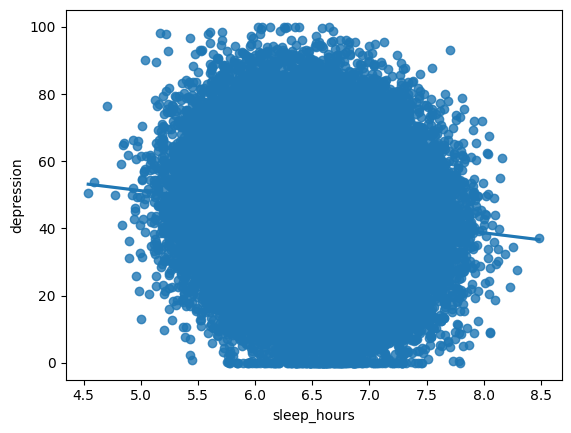

In [101]:
sns.regplot(x="sleep_hours", y="depression", data=df_sample)
plt.show()

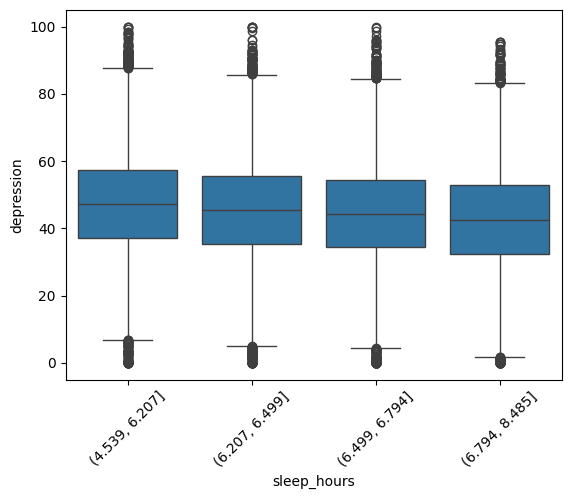

In [102]:
sns.boxplot(x=pd.qcut(df_sample["sleep_hours"], 4), y="depression", data=df_sample)
plt.xticks(rotation=45)
plt.show()

Sleep hours, contrary to the initial hypothesis, appear to have very slight effect on depression, as the values remain nearly identical across all ranges of sleep duration in this dataset.